In [5]:
import pandas as pd
import numpy as np

In [6]:
data = pd.read_csv("../data/books.csv")
print(data.shape)
data


(52478, 25)


,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,11492014-fractured,Fractured,Fateful #2,Cheri Schmidt (Goodreads Author),4.00,The Fateful Trilogy continues with Fractured. ...,English,2940012616562,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...",[],...,NaN,[],871,"['311', '310', '197', '42', '11']",94.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,NaN
52474,11836711-anasazi,Anasazi,Sense of Truth #2,Emma Michaels,4.19,"'Anasazi', sequel to 'The Thirteenth Chime' by...",English,9999999999999,"['Mystery', 'Young Adult']",[],...,August 3rd 2011,[],37,"['16', '14', '5', '2', '0']",95.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,NaN
52475,10815662-marked,Marked,Soul Guardians #1,Kim Richardson (Goodreads Author),3.70,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,English,9781461017097,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...",[],...,March 15th 2011,"[""Readers' Favorite Book Award (2011)""]",6674,"['2109', '1868', '1660', '647', '390']",84.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,7.37
52476,11330278-wayward-son,Wayward Son,NaN,"Tom Pollack (Goodreads Author), John Loftus (G...",3.85,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,English

Hidden missing values ('[]')

In [7]:
print((data['genres'] == '[]').sum())
print((data['characters'] == '[]').sum())
print((data['setting'] == '[]').sum())
print((data['isbn'] == '9999999999999').sum())  # placeholder ISBN
print((data['isbn'] == '0000000000000').sum())

4623
38712
40900
4354
0


### Duplicate values
With these present, recommender may return the same book twice
Duplicate descriptions are often different editions or placeholder text

In [8]:
data['bookId'].duplicated().sum()

np.int64(54)

In [9]:
data.duplicated(['title', 'author']).sum()

np.int64(88)

In [10]:
data['description'].dropna().duplicated().sum()

np.int64(252)

### Popularity and rating reliability
Number of ratings is very skewed. Have to consider weighting/normalization, minimum ratings filter,...

In [11]:
data['numRatings'].describe()

count    5.247800e+04
mean     1.787865e+04
std      1.039448e+05
min      0.000000e+00
25%      3.410000e+02
50%      2.307000e+03
75%      9.380500e+03
max      7.048471e+06
Name: numRatings, dtype: float64

In [12]:
(data['numRatings'] < 10).sum()

np.int64(2444)

In [13]:
(data['numRatings'] == 0).sum()

np.int64(71)

In [14]:
(data['rating'] == 0).sum()

np.int64(71)

### Genre distribution

In [15]:
import ast # because of '[]' type of missing values, treating lists as lists and not as strings

genres = data['genres'].apply(lambda x: ast.literal_eval(x))
genres.explode().value_counts().head(30)

genres
Fiction                    31638
Romance                    15495
Fantasy                    15046
Young Adult                11869
Contemporary               10520
Nonfiction                  8251
Adult                       8246
Novels                      7805
Mystery                     7702
Historical Fiction          7665
Audiobook                   7307
Classics                    6902
Adventure                   6452
Historical                  6383
Paranormal                  6030
Literature                  5836
Science Fiction             5374
Childrens                   5226
Thriller                    4587
Magic                       4248
Humor                       4227
History                     3685
Crime                       3675
Contemporary Romance        3624
Suspense                    3474
Urban Fantasy               3458
Middle Grade                3389
Chick Lit                   3358
Science Fiction Fantasy     3302
Supernatural                3196
Nam

In [16]:
genres.str.len().describe()  # genres per book

count    52478.000000
mean         7.769313
std          3.578427
min          0.000000
25%          6.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: genres, dtype: float64

### Metadata to potentially filter on
- language
- pages
- firstPublishedDate / publishDate
- author

## Exploratory plots

In [17]:
import ast
import sys

import matplotlib.pyplot as plt

sys.path.append("..")
from src.plotting import use_style, hbar, BLUE, BLUE_CMAP, INK_SECONDARY

use_style()

### Description length
This is the text we will embed. `all-MiniLM-L6-v2` reads ~256 tokens (≈1,000 characters) and silently truncates the rest.

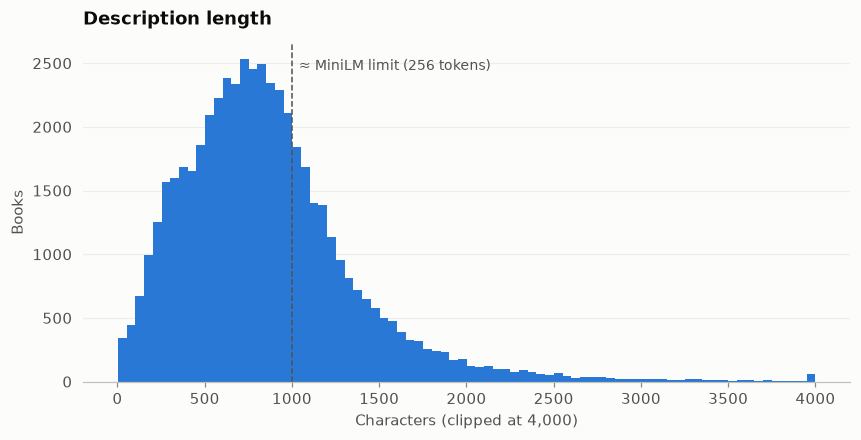

Missing: 1,338  |  under 100 chars: 762  |  over 1,000 chars: 30%


In [18]:
desc_len = data["description"].str.len()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(desc_len.clip(upper=4000), bins=80, color=BLUE)
ax.axvline(1000, color=INK_SECONDARY, linestyle="--", linewidth=1)
ax.text(1040, ax.get_ylim()[1] * 0.92, "≈ MiniLM limit (256 tokens)", color=INK_SECONDARY, fontsize=9)
ax.set(title="Description length", xlabel="Characters (clipped at 4,000)", ylabel="Books")
plt.show()

print(f"Missing: {desc_len.isna().sum():,}  |  under 100 chars: {(desc_len < 100).sum():,}  |  "
      f"over 1,000 chars: {(desc_len > 1000).mean():.0%}")

### Popularity and rating reliability
The number of ratings spans 7 orders of magnitude, so plot it on a log scale. Books with few ratings have extreme averages; they fan out on the left of the right-hand chart.

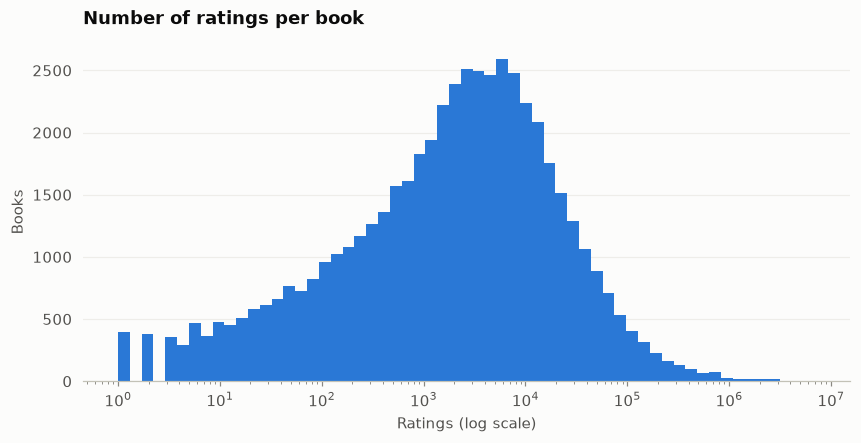

In [19]:
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(0, np.log10(data["numRatings"].max()), 60)
ax.hist(data["numRatings"].clip(lower=1), bins=bins, color=BLUE)
ax.set_xscale("log")
ax.set(title="Number of ratings per book", xlabel="Ratings (log scale)", ylabel="Books")
plt.show()

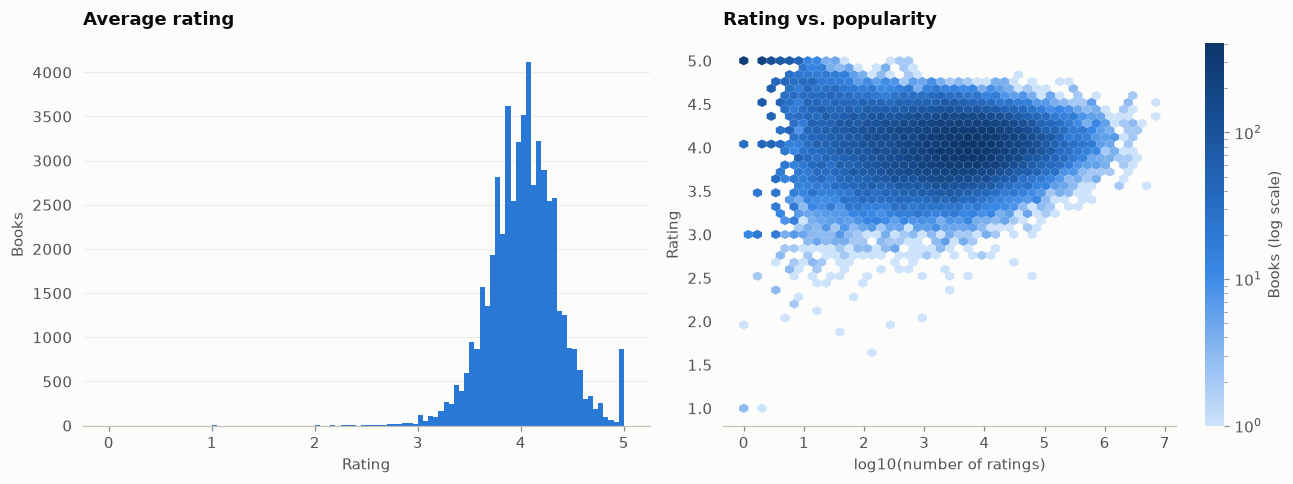

In [20]:
rated = data[data["numRatings"] > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.hist(rated["rating"], bins=np.arange(0, 5.05, 0.05), color=BLUE)
ax1.set(title="Average rating", xlabel="Rating", ylabel="Books")

hb = ax2.hexbin(np.log10(rated["numRatings"]), rated["rating"], gridsize=45,
                cmap=BLUE_CMAP, bins="log", mincnt=1, linewidths=0)
ax2.grid(False)
ax2.set(title="Rating vs. popularity", xlabel="log10(number of ratings)", ylabel="Rating")
fig.colorbar(hb, ax=ax2, label="Books (log scale)").outline.set_visible(False)
plt.tight_layout()
plt.show()

### Genres
`genres` is a list stored as a string, so it's parsed with `ast.literal_eval`. Tags like *Fiction*, *Adult* and *Novels* are so common they barely distinguish books. The scrape kept at most 10 tags per book.

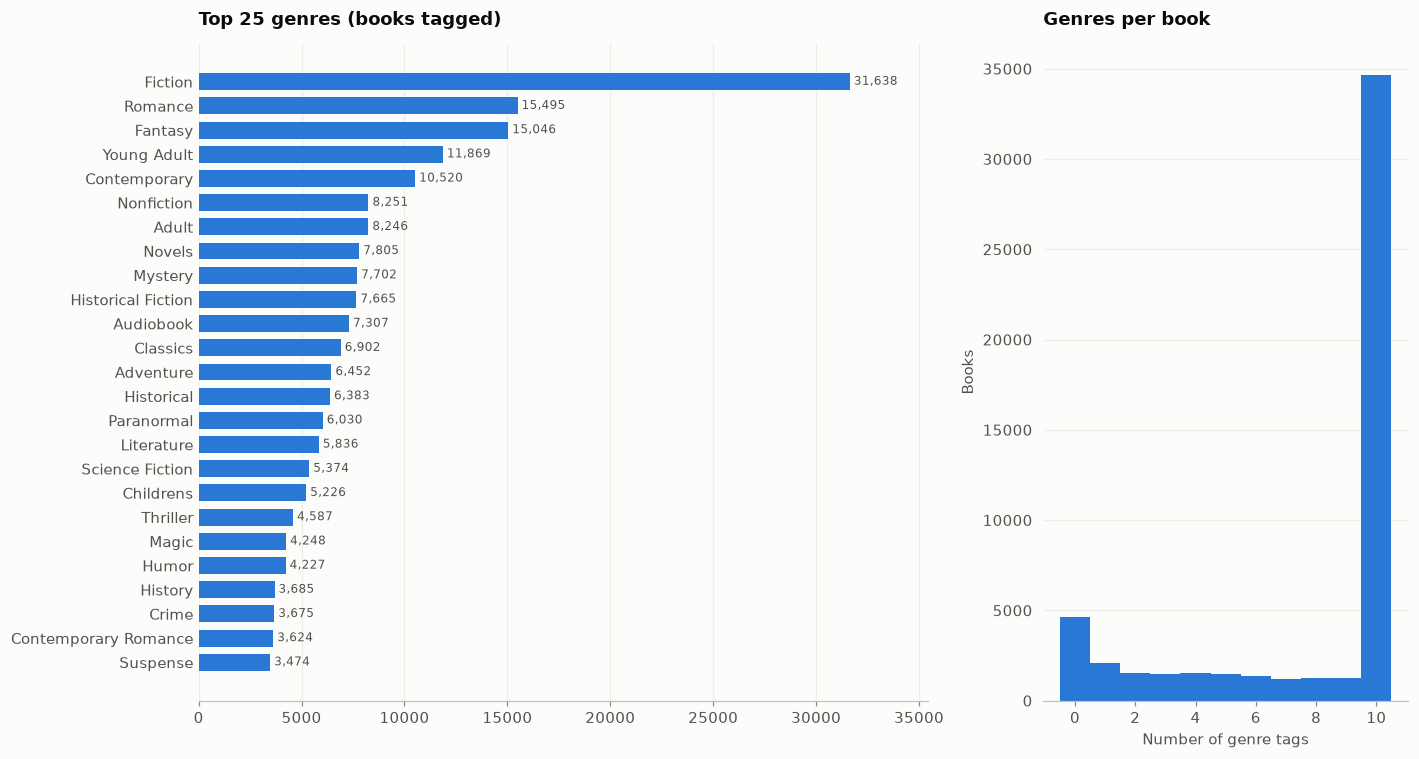

In [21]:
genres = data["genres"].apply(ast.literal_eval)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [2, 1]})
hbar(ax1, genres.explode().value_counts().head(25), "Top 25 genres (books tagged)")

per_book = genres.str.len()
ax2.hist(per_book, bins=np.arange(-0.5, per_book.max() + 1.5, 1), color=BLUE)
ax2.set(title="Genres per book", xlabel="Number of genre tags", ylabel="Books")
plt.tight_layout()
plt.show()

### Language

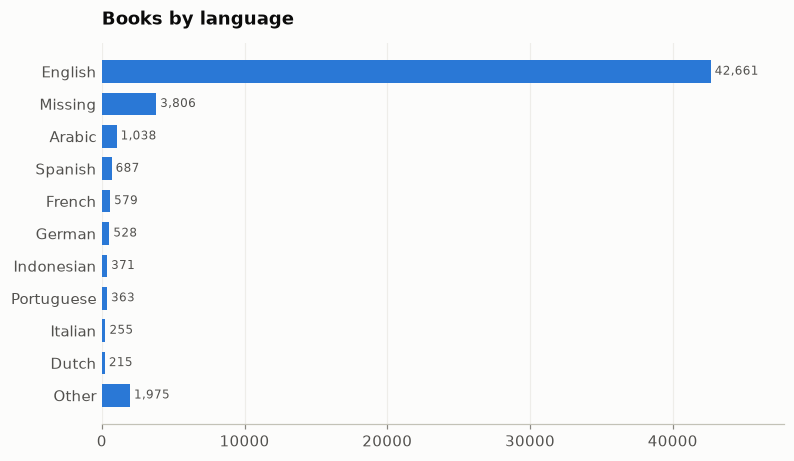

In [22]:
languages = data["language"].fillna("Missing").value_counts()
top = languages.head(10)
top["Other"] = languages.iloc[10:].sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
hbar(ax, top, "Books by language")
plt.show()

### Edition year
Both date columns sometimes use 2-digit years, which lose the century: *The Odyssey* has `firstPublishDate` `10/28/00` and *Pride and Prejudice* has `01/28/13`. The original publication year can't be recovered, so this plots the year of the **edition** Goodreads lists (`publishDate`). For 2-digit edition years, `yy` ≤ 20 is read as 20yy, otherwise 19yy.

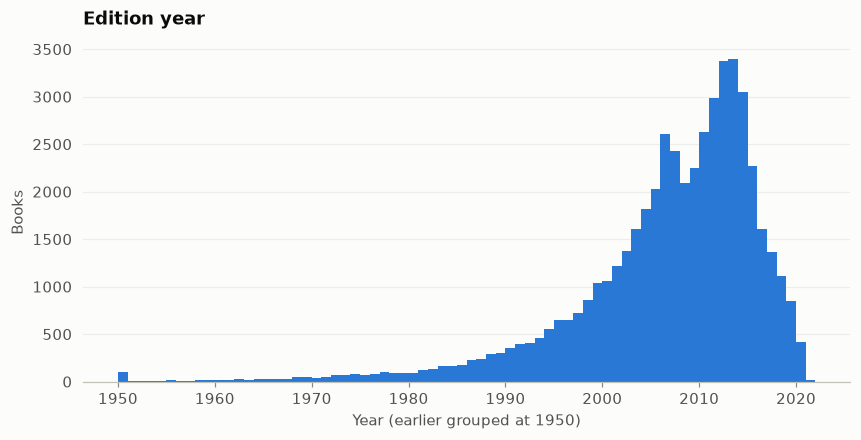

Year unknown: 1,680


In [23]:
four_digit = pd.to_numeric(data["publishDate"].str.extract(r"(\d{4})")[0], errors="coerce")
two_digit = pd.to_numeric(data["publishDate"].str.extract(r"^\d{2}/\d{2}/(\d{2})$")[0], errors="coerce")
two_digit_year = two_digit + np.where(two_digit <= 20, 2000, 1900)
data["edition_year"] = four_digit.fillna(two_digit_year)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(data["edition_year"].clip(lower=1950), bins=np.arange(1950, 2023, 1), color=BLUE)
ax.set(title="Edition year", xlabel="Year (earlier grouped at 1950)", ylabel="Books")
plt.show()

print(f"Year unknown: {data['edition_year'].isna().sum():,}")

### Pages

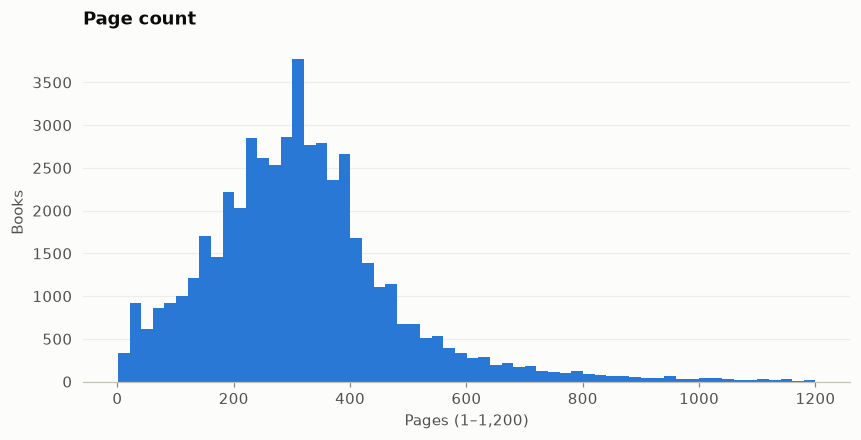

Missing: 2,347  |  0 pages: 164  |  over 1,200: 380


In [24]:
pages = pd.to_numeric(data["pages"].str.extract(r"(\d+)")[0], errors="coerce")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pages[(pages > 0) & (pages <= 1200)], bins=60, color=BLUE)
ax.set(title="Page count", xlabel="Pages (1–1,200)", ylabel="Books")
plt.show()

print(f"Missing: {pages.isna().sum():,}  |  0 pages: {(pages == 0).sum():,}  |  over 1,200: {(pages > 1200).sum():,}")

### Most represented authors
The `(Goodreads Author)` suffix is stripped, otherwise the same person counts twice.

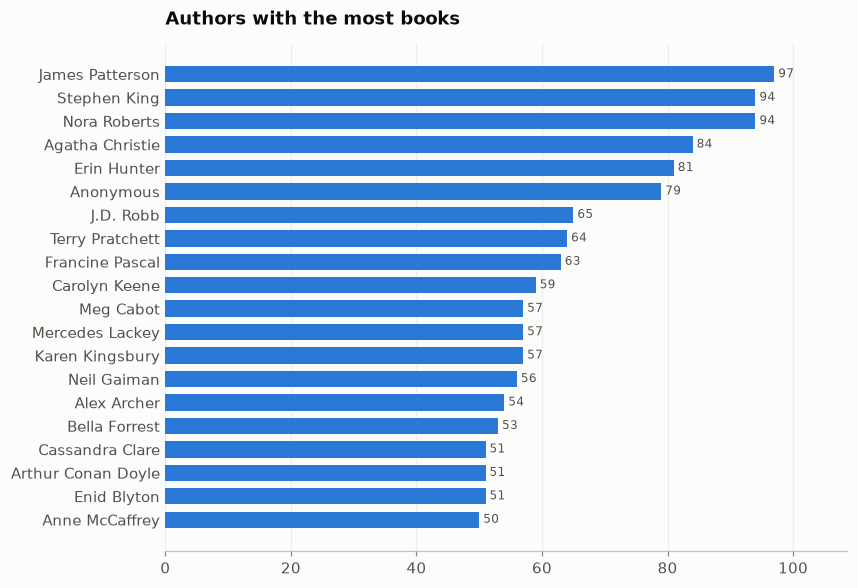

In [25]:
authors = data["author"].str.replace(r"\s*\(.*?\)", "", regex=True).str.split(",").str[0].str.strip()

fig, ax = plt.subplots(figsize=(8, 6))
hbar(ax, authors.value_counts().head(20), "Authors with the most books")
plt.show()

#### Remove non-english books

In [28]:
from src.catalog.normalize import is_english
data = data[is_english(data["language"], keep_missing=True)]
data

,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price,edition_year
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09,2008.0
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38,2004.0
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN,2006.0
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN,2000.0
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52473,11492014-fractured,Fractured,Fateful #2,Cheri Schmidt (Goodreads Author),4.00,The Fateful Trilogy continues with Fractured. ...,English,2940012616562,"['Vampires', 'Paranormal', 'Young Adult', 'Rom...",[],...,[],871,"['311', '310', '197', '42', '11']",94.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,NaN,2011.0
52474,11836711-anasazi,Anasazi,Sense of Truth #2,Emma Michaels,4.19,"'Anasazi', sequel to 'The Thirteenth Chime' by...",English,9999999999999,"['Mystery', 'Young Adult']",[],...,[],37,"['16', '14', '5', '2', '0']",95.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,NaN,2011.0
52475,10815662-marked,Marked,Soul Guardians #1,Kim Richardson (Goodreads Author),3.70,--READERS FAVORITE AWARDS WINNER 2011--Sixteen...,English,9781461017097,"['Fantasy', 'Young Adult', 'Paranormal', 'Ange...",[],...,"[""Readers' Favorite Book Award (2011)""]",6674,"['2109', '1868', '1660', '647', '390']",84.0,[],https://i.gr-assets.com/images/S/compressed.ph...,0,1,7.37,2011.0
52476,11330278-wayward-son,Wayward Son,NaN,"Tom Pollack (Goodreads Author), John Loftus (G...",3.85,A POWERFUL TREMOR UNEARTHS AN ANCIENT SECRETBu...,English,9781450755634,"['Fictio